# Naruto Hand Sign with CNN Training
Fine-tunes **MobileNetV2** and **SqueezeNet1_1** with transfer learning on the collected hand sign images.
- 75% of backbone frozen, last 25% trainable
- 50 epochs, Adam optimizer, categorical cross-entropy loss
- Cosine LR schedule, saves best checkpoint per model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from pathlib import Path
import os
import json
import matplotlib.pyplot as plt

## Configuration

In [2]:
DATA_DIR = 'data/images'
MODEL_DIR = 'model'
LABEL_MAP_FILE = 'model/label_map.json'
os.makedirs(MODEL_DIR, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-4
FREEZE_RATIO = 0.75
PATIENCE = 8
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp'}

## Data Augmentation & Transforms

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

## Model Definitions

In [4]:
def freeze_75_percent(layers):
    n = len(layers)
    freeze_up_to = int(n * FREEZE_RATIO)
    for i, layer in enumerate(layers):
        for param in layer.parameters():
            param.requires_grad = (i >= freeze_up_to)


def build_mobilenet(num_classes):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    freeze_75_percent(list(model.features))
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.last_channel, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


def build_squeezenet(num_classes):
    model = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.DEFAULT)
    freeze_75_percent(list(model.features))
    model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
    model.num_classes = num_classes
    return model

## Dataset & DataLoaders

In [5]:
class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, label = self.dataset[self.indices[i]]
        return self.transform(img), label


# Skip empty class folders
data_path = Path(DATA_DIR)
empty = [d for d in data_path.iterdir() if d.is_dir() and not any(
    f.suffix.lower() in VALID_EXTENSIONS for f in d.iterdir() if f.is_file()
)]
if empty:
    print(f"Skipping empty classes: {[d.name for d in empty]}")
renamed = {}
for d in empty:
    new_path = d.parent / f'_skip_{d.name}'
    d.rename(new_path)
    renamed[new_path] = d

full_dataset = datasets.ImageFolder(DATA_DIR)
num_classes = len(full_dataset.classes)
print(f"Classes ({num_classes}): {full_dataset.classes}")
print(f"Total samples: {len(full_dataset)}")

label_map = {i: name for i, name in enumerate(full_dataset.classes)}
with open(LABEL_MAP_FILE, 'w') as f:
    json.dump(label_map, f, indent=2)

n_val = max(1, int(0.15 * len(full_dataset)))
n_train = len(full_dataset) - n_val
train_idx, val_idx = random_split(
    range(len(full_dataset)), [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

full_dataset_raw = datasets.ImageFolder(DATA_DIR, transform=None)
train_ds = SubsetWithTransform(full_dataset_raw, train_idx.indices, train_transform)
val_ds   = SubsetWithTransform(full_dataset_raw, val_idx.indices,   val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, num_workers=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  {n_train} train / {n_val} val")

Classes (12): ['Bird', 'Boar', 'Dog', 'Dragon', 'Hare', 'Horse', 'Monkey', 'Ox', 'Ram', 'Rat', 'Snake', 'Tiger']
Total samples: 784
Device: cpu  |  667 train / 117 val


## Training Loop

In [6]:
def train_model(model, model_name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    model_file = os.path.join(MODEL_DIR, f"{model_name}.pt")
    best_val_acc = 0.0
    patience_counter = 0
    train_accs = []
    val_accs = []

    print(f"{'='*50}")
    print(f"Training {model_name}  |  trainable params: {sum(p.numel() for p in trainable_params):,}")
    print(f"{'='*50}")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0
        correct_train = total_train = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct_train += (out.detach().argmax(dim=1) == labels).sum().item()
            total_train += len(labels)
        scheduler.step()
        train_acc = correct_train / total_train

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs).argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += len(labels)
        val_acc = correct / total if total > 0 else 0.0

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), model_file)
        else:
            patience_counter += 1

        print(f"Epoch {epoch:3d}/{EPOCHS} | loss: {total_loss/len(train_loader):.4f} | train acc: {train_acc:.3f} | val acc: {val_acc:.3f} | patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    print(f"Best val accuracy: {best_val_acc:.3f}  ->  saved to {model_file}")
    return best_val_acc, train_accs, val_accs

## Train MobileNetV2

In [7]:
mobilenet_acc, mobilenet_train_accs, mobilenet_val_accs = train_model(build_mobilenet(num_classes), 'mobilenet_v2')

Training mobilenet_v2  |  trainable params: 2,012,364
Epoch   1/50 | loss: 2.4575 | train acc: 0.168 | val acc: 0.376 | patience: 0/8
Epoch   2/50 | loss: 2.2983 | train acc: 0.378 | val acc: 0.615 | patience: 0/8
Epoch   3/50 | loss: 1.8723 | train acc: 0.640 | val acc: 0.795 | patience: 0/8
Epoch   4/50 | loss: 1.1856 | train acc: 0.805 | val acc: 0.863 | patience: 0/8
Epoch   5/50 | loss: 0.6222 | train acc: 0.894 | val acc: 0.915 | patience: 0/8
Epoch   6/50 | loss: 0.3689 | train acc: 0.933 | val acc: 0.949 | patience: 0/8
Epoch   7/50 | loss: 0.2402 | train acc: 0.955 | val acc: 0.957 | patience: 0/8
Epoch   8/50 | loss: 0.1981 | train acc: 0.948 | val acc: 0.966 | patience: 0/8
Epoch   9/50 | loss: 0.1827 | train acc: 0.954 | val acc: 0.966 | patience: 1/8
Epoch  10/50 | loss: 0.1511 | train acc: 0.970 | val acc: 0.957 | patience: 2/8
Epoch  11/50 | loss: 0.1301 | train acc: 0.963 | val acc: 0.974 | patience: 0/8
Epoch  12/50 | loss: 0.1141 | train acc: 0.972 | val acc: 0.974 | 

## Train SqueezeNet1_1

In [8]:
squeezenet_acc, squeezenet_train_accs, squeezenet_val_accs = train_model(build_squeezenet(num_classes), 'squeezenet1_1')

Training squeezenet1_1  |  trainable params: 608,236
Epoch   1/50 | loss: 2.4754 | train acc: 0.139 | val acc: 0.325 | patience: 0/8
Epoch   2/50 | loss: 1.8528 | train acc: 0.420 | val acc: 0.624 | patience: 0/8
Epoch   3/50 | loss: 1.0559 | train acc: 0.660 | val acc: 0.812 | patience: 0/8
Epoch   4/50 | loss: 0.5466 | train acc: 0.813 | val acc: 0.863 | patience: 0/8
Epoch   5/50 | loss: 0.3998 | train acc: 0.883 | val acc: 0.906 | patience: 0/8
Epoch   6/50 | loss: 0.3068 | train acc: 0.909 | val acc: 0.940 | patience: 0/8
Epoch   7/50 | loss: 0.2387 | train acc: 0.934 | val acc: 0.923 | patience: 1/8
Epoch   8/50 | loss: 0.2621 | train acc: 0.915 | val acc: 0.940 | patience: 2/8
Epoch   9/50 | loss: 0.2179 | train acc: 0.942 | val acc: 0.966 | patience: 0/8
Epoch  10/50 | loss: 0.1334 | train acc: 0.961 | val acc: 0.949 | patience: 1/8
Epoch  11/50 | loss: 0.1228 | train acc: 0.964 | val acc: 0.957 | patience: 2/8
Epoch  12/50 | loss: 0.1270 | train acc: 0.958 | val acc: 0.940 | p

## Results

In [9]:
results = {'mobilenet_v2': mobilenet_acc, 'squeezenet1_1': squeezenet_acc}
print(f"\n{'='*50}")
print("Final Results:")
for name, acc in results.items():
    print(f"  {name}: {acc:.3f} val acc")
best = max(results, key=results.get)
print(f"Best model: {best}  â†’  model/{best}.pt")
print(f"Label map saved to {LABEL_MAP_FILE}")

# Restore any renamed empty folders
for new_path, original in renamed.items():
    if new_path.exists():
        new_path.rename(original)


Final Results:
  mobilenet_v2: 0.983 val acc
  squeezenet1_1: 0.966 val acc
Best model: mobilenet_v2  â†’  model/mobilenet_v2.pt
Label map saved to model/label_map.json


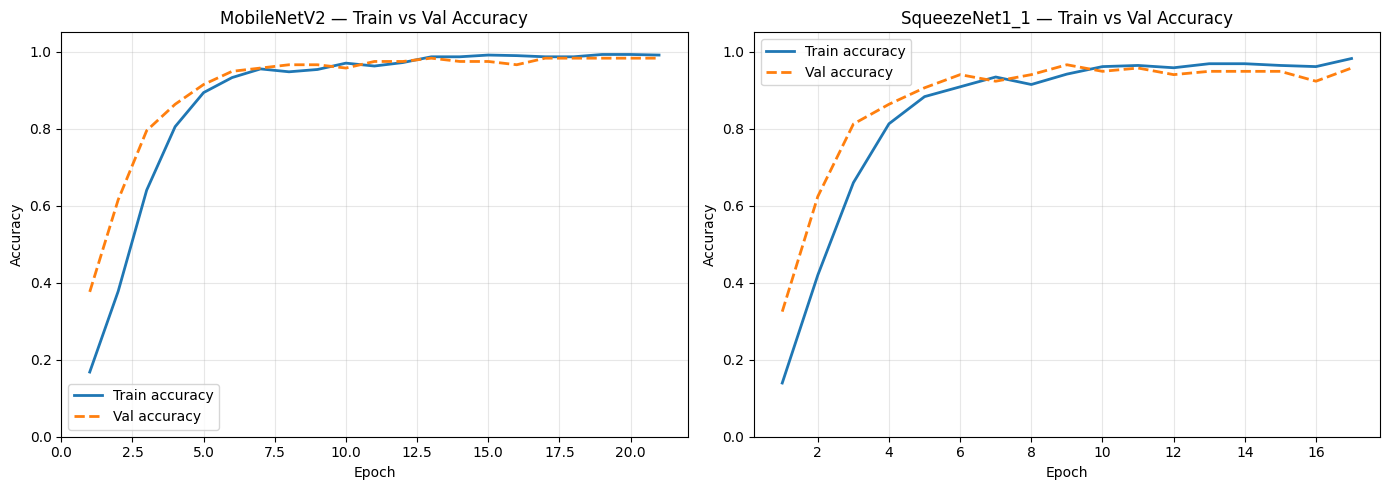

Saved to model/acc_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, train_accs, val_accs in [
    (axes[0], 'MobileNetV2',   mobilenet_train_accs,   mobilenet_val_accs),
    (axes[1], 'SqueezeNet1_1', squeezenet_train_accs, squeezenet_val_accs),
]:
    epochs = range(1, len(train_accs) + 1)
    ax.plot(epochs, train_accs, label='Train accuracy', linewidth=2)
    ax.plot(epochs, val_accs,   label='Val accuracy',   linewidth=2, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{name} — Train vs Val Accuracy')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model/acc_curves.png', dpi=150)
plt.show()
print("Saved to model/acc_curves.png")